# Comparaison des modèles (Students Social Media Addiction)

**Dataset :** Mobile Addiction  
**Variable cible :** `Addiction_Level` score d'addiction (Low, Moderate, Severe, High)

Ce notebook charge les données, fait le preprocessing, puis appelle chaque modèle depuis le dossier `models/`.  
Il compare ensuite les résultats et propose un exemple d'application concret.

## 1 - Importation des bibliothèques

In [23]:
import seaborn as sns
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder

from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from sklearn.metrics import (mean_absolute_error, mean_squared_error,
                             r2_score)

from sklearn.linear_model import SGDClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn import tree

import sys
sys.path.append('..')

from sklearn.model_selection import train_test_split
from models.encoder import labelEncoder, oneHotEncoder
from models.ACP import ACP

## 2 - Chargement et preprocessing

On charge le dataset, on supprime la colonne `User_ID` (identifiant sans valeur prédictive),  
et on convertit les variables textuelles en nombres avec `LabelEncoder`.  
Ensuite on sépare les données en 80% entraînement / 20% test.

In [27]:
df = pd.read_csv('BDD_initial/mobile_addiction_data.csv', sep='\t')
df = df.drop(columns=['User_ID'])

X_raw = df.drop(columns=['Addiction_Level'])
y_raw = df['Addiction_Level']

# Encoder y dans le bon ordre
le_y = LabelEncoder()
le_y.classes_ = np.array(['Low', 'Moderate', 'High', 'Severe'])
y = le_y.transform(y_raw)  # Low=0, Moderate=1, High=2, Severe=3

# Encoder X
X_le  = labelEncoder(X_raw.copy())
X_ohe = oneHotEncoder(X_raw.copy())
#x_acp = ACP(X_ohe, n_components=50)

# Splits
X_train_le,  X_test_le,  y_train_le,  y_test_le  = train_test_split(X_le,  y, test_size=0.2, random_state=42)
X_train_ohe, X_test_ohe, y_train_ohe, y_test_ohe = train_test_split(X_ohe, y, test_size=0.2, random_state=42)
#X_train_acp, X_test_acp, y_train_acp, y_test_acp = train_test_split(x_acp, y, test_size=0.2, random_state=42)

# label_encoders pour l'exemple étudiant
cat_cols = X_raw.select_dtypes(include='object').columns.tolist()
label_encoders = {}
for col in cat_cols:
    le = LabelEncoder()
    le.fit(X_raw[col])
    label_encoders[col] = le

print('X_le  shape:', X_le.shape)
print('X_ohe shape:', X_ohe.shape)
print('X_acp shape:', x_acp.shape)
print('Train / Test:', X_train_le.shape[0], '/', X_test_le.shape[0])

X_le  shape: (3000, 33)
X_ohe shape: (3000, 22519)
X_acp shape: (3000, 50)
Train / Test: 2400 / 600


## 3. Entraînement des modèles

Chaque modèle est dans un fichier séparé dans `models/`.  
La fonction `run(X_train, X_test, y_train, y_test)` retourne un dictionnaire avec les métriques.

> **Pour ajouter un modèle** : importer sa fonction `run` et l'ajouter au dictionnaire `modeles`.

In [28]:
import sys
sys.path.append('..')

from models.random_forest_rgs_v2 import run as run_rf
from models.xgboost_rgs_v2 import run as run_xgb
from models.knn_rgs import run as run_knn
from models.naive_bayes_rgs_v2 import run as run_nb_rgs

modeles = {
    'KNN'          : run_knn,
    'Naive Bayes rgs'  : run_nb_rgs,
    'XGBoost'      : run_xgb,
    'Random Forest': run_rf,
}

resultats = {}
for nom, run_fn in modeles.items():
    print(f'Entraînement : {nom}...')
    resultats[f'{nom} (LE)']  = run_fn(X_train_le,  X_test_le,  y_train_le, y_test_le)
    resultats[f'{nom} (ACP)'] = run_fn(X_train_ohe, X_test_ohe, y_train_ohe, y_test_ohe)
    #resultats[f'{nom} (ACP)'] = run_fn(X_train_acp, X_test_acp, y_train_acp, y_test_acp)



    print(f"  LE  R²: {resultats[f'{nom} (LE)']['optimized']['r2']:.4f}")
    print(f"  ACP R²: {resultats[f'{nom} (ACP)']['optimized']['r2']:.4f}")

print('\nTerminé.')

Entraînement : KNN...
  LE  R²: -0.0601
  ACP R²: -0.0653
Entraînement : Naive Bayes rgs...
  LE  R²: -0.0151
  ACP R²: -0.8684
Entraînement : XGBoost...
  LE  R²: -0.0081
  ACP R²: -0.0169
Entraînement : Random Forest...
  LE  R²: -0.0047
  ACP R²: -0.0114

Terminé.


## 4. Tableau comparatif

On compare les modèles sur trois métriques :
- **R²** : proportion de variance expliquée (plus c'est proche de 1, mieux c'est)
- **MAE** : erreur moyenne en points de score
- **RMSE** : similaire au MAE, mais pénalise plus les grandes erreurs

In [29]:
rows = []
for nom, res in resultats.items():
    opt = res['optimized']
    rows.append({
        'Modèle': nom,
        'R²'    : round(opt['r2'],   4),
        'MAE'   : round(opt['mae'],  4),
        'RMSE'  : round(opt['rmse'], 4),
    })

df_comparaison = pd.DataFrame(rows).sort_values('R²', ascending=False).set_index('Modèle')
df_comparaison

,R²,MAE,RMSE
Modèle,,,
Random Forest (LE),-0.0047,0.9634,1.0889
XGBoost (LE),-0.0081,0.9646,1.0907
Random Forest (ACP),-0.0114,0.9711,1.0925
Naive Bayes rgs (LE),-0.0151,0.9623,1.0945
XGBoost (ACP),-0.0169,0.9742,1.0955
KNN (LE),-0.0601,0.9726,1.1185
KNN (ACP),-0.0653,0.9573,1.1213
Naive Bayes rgs (ACP),-0.8684,1.1650,1.4849


## 5. Visualisation des métriques

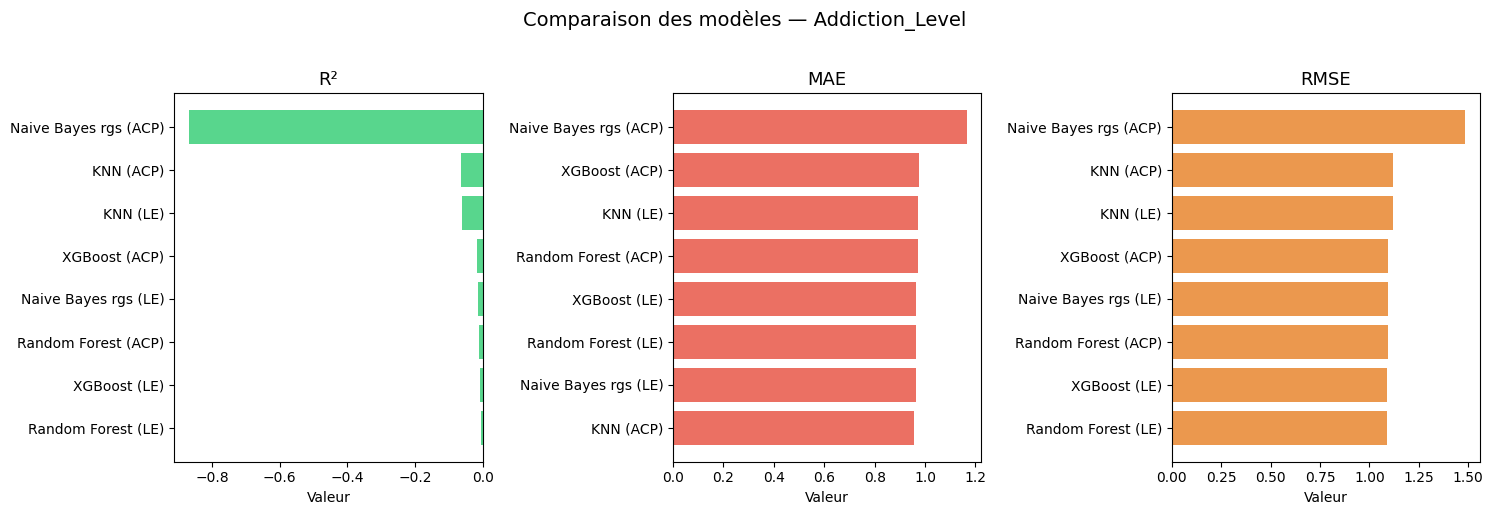

In [30]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

metrics = [('R²', '#2ecc71', False), ('MAE', '#e74c3c', True), ('RMSE', '#e67e22', True)]

for ax, (metric, color, ascending) in zip(axes, metrics):
    vals = df_comparaison[metric].sort_values(ascending=ascending)
    ax.barh(vals.index, vals.values, color=color, alpha=0.8)
    ax.set_title(metric, fontsize=13)
    ax.set_xlabel('Valeur')

plt.suptitle('Comparaison des modèles — Addiction_Level', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## 6. Exemple d'application

On crée un profil d'étudiant fictif et on demande au modèle de prédire son score d'addiction.  
Les variables catégorielles sont encodées avec les mêmes `LabelEncoder` utilisés à l'étape 2.

In [36]:
etudiant = {
    'Country'                        : 'USA',
    'Age'                            : 20,
    'Gender'                         : 'Male',
    'Occupation'                     : 'Student',
    'Education_Level'                : 'High School',
    'Income_USD'                     : 15000,
    'Daily_Screen_Time_Hours'        : 5.0,
    'Phone_Unlocks_Per_Day'          : 50,
    'Social_Media_Usage_Hours'       : 4.0,
    'Gaming_Usage_Hours'             : 1.0,
    'Streaming_Usage_Hours'          : 0.5,
    'Messaging_Usage_Hours'          : 0.5,
    'Work_Related_Usage_Hours'       : 0.0,
    'Sleep_Hours'                    : 6.0,
    'Physical_Activity_Hours'        : 1.0,
    'Mental_Health_Score'            : 13.0,
    'Depression_Score'               : 20.0,
    'Anxiety_Score'                  : 15.0,
    'Stress_Level'                   : 18.0,
    'Relationship_Status'            : 'Single',
    'Has_Children'                   : 'No',
    'Urban_or_Rural'                 : 'Urban',
    'Time_Spent_With_Family_Hours'   : 1.0,
    'Online_Shopping_Hours'          : 0.5,
    'Internet_Connection_Type'       : 'WiFi',
    'Primary_Device_Brand'           : 'Apple',
    'Has_Screen_Time_Management_App' : 'No',
    'Monthly_Data_Usage_GB'          : 10.0,
    'Has_Night_Mode_On'              : 'Yes',
    'Age_First_Phone'                : 12,
    'Push_Notifications_Per_Day'     : 30,
    'Tech_Savviness_Score'           : 7.0,
    'Addiction_screen'               : 1.0,
}

cols_cat_reelles = [
    'Country', 'Gender', 'Occupation', 'Education_Level',
    'Relationship_Status', 'Has_Children', 'Urban_or_Rural',
    'Internet_Connection_Type', 'Primary_Device_Brand',
    'Has_Screen_Time_Management_App', 'Has_Night_Mode_On'
]

etudiant_enc = {}
for col, val in etudiant.items():
    if col in cols_cat_reelles and col in label_encoders:
        etudiant_enc[col] = label_encoders[col].transform([val])[0]
    else:
        etudiant_enc[col] = val

X_etudiant = pd.DataFrame([etudiant_enc])[X_le.columns]

best_rf = resultats['Random Forest (LE)']['model']
pred_encoded = best_rf.predict(X_etudiant)[0]
pred_label   = le_y.inverse_transform([round(pred_encoded)])[0]

print("=== Profil de l'étudiant ===")
for k, v in etudiant.items():
    print(f"  {k:<40} : {v}")

print(f"\n  Niveau d'addiction prédit : {pred_label}")

=== Profil de l'étudiant ===
  Country                                  : USA
  Age                                      : 20
  Gender                                   : Male
  Occupation                               : Student
  Education_Level                          : High School
  Income_USD                               : 15000
  Daily_Screen_Time_Hours                  : 5.0
  Phone_Unlocks_Per_Day                    : 50
  Social_Media_Usage_Hours                 : 4.0
  Gaming_Usage_Hours                       : 1.0
  Streaming_Usage_Hours                    : 0.5
  Messaging_Usage_Hours                    : 0.5
  Work_Related_Usage_Hours                 : 0.0
  Sleep_Hours                              : 6.0
  Physical_Activity_Hours                  : 1.0
  Mental_Health_Score                      : 13.0
  Depression_Score                         : 20.0
  Anxiety_Score                            : 15.0
  Stress_Level                             : 18.0
  Relationship_Status  